# Population Trends Analysis

This notebook analyzes U.S. population trends by year using the **apportionment.csv** dataset.

In [1]:

import pandas as pd
import io

# Load data from uploaded file
csv_text = '''Name,Geography Type,Year,Resident Population,Percent Change in Resident Population,Resident Population Density,Resident Population Density Rank,Number of Representatives,Change in Number of Representatives,Average Apportionment Population Per Representative
Alabama,State,1910,"2,138,093",16.9,42.2,25,10,1,"213,809"
Alaska,State,1910,"64,356",1.2,0.1,52,,,
Arizona,State,1910,"204,354",66.2,1.8,49,,,
Arkansas,State,1910,"1,574,449",20,30.3,30,7,0,"224,921"
California,State,1910,"2,377,549",60.1,15.3,38,11,3,"216,051"
Colorado,State,1910,"799,024",48,7.7,42,4,1,"199,643"
Connecticut,State,1910,"1,114,756",22.7,230.2,6,5,0,"222,951"
Delaware,State,1910,"202,322",9.5,103.8,11,1,0,"202,322"
District of Columbia,State,1910,"331,069",18.8,"5,423.10",1,,,
Florida,State,1910,"752,619",42.4,14,40,4,1,"188,155"
Georgia,State,1910,"2,609,121",17.7,45.4,23,12,1,"217,427"
Hawaii,State,1910,"191,909",24.6,29.9,31,,,
Idaho,State,1910,"325,594",101.3,3.9,46,2,1,"161,720"
Illinois,State,1910,"5,638,591",16.9,101.6,12,27,2,"208,837"
Indiana,State,1910,"2,700,876",7.3,75.4,13,13,0,"207,760"
Iowa,State,1910,"2,224,771",-0.3,39.8,26,11,0,"202,252"
Kansas,State,1910,"1,690,949",15,20.7,35,8,0,"211,369"
Kentucky,State,1910,"2,289,905",6.6,58,14,11,0,"208,173"
Louisiana,State,1910,"1,656,388",19.9,38.3,29,8,1,"207,049"
Maine,State,1910,"742,371",6.9,24.1,33,4,0,"185,593"
Maryland,State,1910,"1,295,346",9,133.4,9,6,0,"215,891"
Massachusetts,State,1910,"3,366,416",20,431.6,3,16,2,"210,401"
Michigan,State,1910,"2,810,173",16.1,49.7,19,13,1,"216,167"
Minnesota,State,1910,"2,075,708",18.5,26.1,32,10,1,"207,438"
Mississippi,State,1910,"1,797,114",15.8,38.3,28,8,0,"224,639"
Missouri,State,1910,"3,293,335",6,47.9,21,16,0,"205,833"
Montana,State,1910,"376,053",54.5,2.6,48,2,1,"183,169"
Nebraska,State,1910,"1,192,214",11.8,15.5,37,6,0,"198,702"
Nevada,State,1910,"81,875",93.4,0.7,51,1,0,"80,293"
New Hampshire,State,1910,"430,572",4.6,48.1,20,2,0,"215,286"
New Jersey,State,1910,"2,537,167",34.7,345,4,12,2,"211,431"
New Mexico,State,1910,"327,301",67.6,2.7,47,,,
New York,State,1910,"9,113,614",25.4,193.4,7,43,6,"211,836"
North Carolina,State,1910,"2,206,287",16.5,45.4,22,10,0,"220,629"
North Dakota,State,1910,"577,056",80.8,8.4,41,3,1,"191,468"
Ohio,State,1910,"4,767,121",14.7,116.7,10,22,1,"216,687"
Oklahoma,State,1910,"1,657,155",109.7,24.2,33,8,8,"207,144"
Oregon,State,1910,"672,765",62.7,7,44,3,1,"224,255"
Pennsylvania,State,1910,"7,665,111",21.6,171.3,8,36,4,"212,920"
Puerto Rico,State,1910,"1,118,012",17.3,326.5,5,,,
Rhode Island,State,1910,"542,610",26.6,524.9,2,3,1,"180,870"
South Carolina,State,1910,"1,515,400",13.1,50.4,18,7,0,"216,486"
South Dakota,State,1910,"583,888",45.4,7.7,42,3,1,"191,892"
Tennessee,State,1910,"2,184,789",8.1,53,15,10,0,"218,479"
Texas,State,1910,"3,896,542",27.8,14.9,39,18,2,"216,475"
Utah,State,1910,"373,351",34.9,4.5,45,2,1,"185,932"
Vermont,State,1910,"355,956",3.6,38.6,27,2,0,"177,978"
Virginia,State,1910,"2,061,612",11.2,52.2,16,10,0,"206,161"
Washington,State,1910,"1,141,990",120.4,17.2,36,5,2,"228,027"
West Virginia,State,1910,"1,221,119",27.4,50.8,17,6,1,"203,520"
Wisconsin,State,1910,"2,333,860",12.8,43.1,24,11,0,"212,078"
Wyoming,State,1910,"145,965",57.7,1.5,50,1,0,"144,658"
Midwest Region,Region,1910,"29,888,542",13.5,,,,,
Northeast Region,Region,1910,"25,868,573",22.9,,,,,
South Region,Region,1910,"29,389,330",19.8,,,,,
West Region,Region,1910,"7,082,086",64.4,,,,,
United States,Nation,1910,"92,228,531",21,26,,433,47,"210,328"
Alabama,State,1920,"2,348,174",9.8,46.4,25,10,0,"234,817"
Alaska,State,1920,"55,036",-14.5,0.1,52,,,
Arizona,State,1920,"334,162",63.5,2.9,49,1,1,"309,495"
Arkansas,State,1920,"1,752,204",11.3,33.7,31,7,0,"250,315"
California,State,1920,"3,426,861",44.1,22,35,11,0,"311,457"
Colorado,State,1920,"939,629",17.6,9.1,42,4,0,"234,790"
Connecticut,State,1920,"1,380,631",23.9,285.1,6,5,0,"276,126"
Delaware,State,1920,"223,003",10.2,114.4,12,1,0,"223,003"
District of Columbia,State,1920,"437,571",32.2,"7,167.60",1,,,
Florida,State,1920,"968,470",28.7,18.1,38,4,0,"242,118"
Georgia,State,1920,"2,895,832",11,50.4,21,12,0,"241,319"
Hawaii,State,1920,"255,912",33.4,39.8,28,,,
Idaho,State,1920,"431,866",32.6,5.2,46,2,0,"215,221"
Illinois,State,1920,"6,485,280",15,116.8,11,27,0,"240,196"
Indiana,State,1920,"2,930,390",8.5,81.8,13,13,0,"225,415"
Iowa,State,1920,"2,404,021",8.1,43,26,11,0,"218,547"
Kansas,State,1920,"1,769,257",4.6,21.6,36,8,0,"221,157"
Kentucky,State,1920,"2,416,630",5.5,61.2,15,11,0,"219,694"
Louisiana,State,1920,"1,798,509",8.6,41.6,27,8,0,"224,814"
Maine,State,1920,"768,014",3.5,24.9,34,4,0,"192,004"
Maryland,State,1920,"1,449,661",11.9,149.3,9,6,0,"241,610"
Massachusetts,State,1920,"3,852,356",14.4,493.9,3,16,0,"240,772"
Michigan,State,1920,"3,668,412",30.5,64.9,14,13,0,"282,186"
Minnesota,State,1920,"2,387,125",15,30,32,10,0,"238,566"
Mississippi,State,1920,"1,790,618",-0.4,38.2,29,8,0,"223,827"
Missouri,State,1920,"3,404,055",3.4,49.5,22,16,0,"212,753"
Montana,State,1920,"548,889",46,3.8,47,2,0,"270,756"
Nebraska,State,1920,"1,296,372",8.7,16.9,40,6,0,"216,062"
Nevada,State,1920,"77,407",-5.5,0.7,51,1,0,"75,820"
New Hampshire,State,1920,"443,083",2.9,49.5,22,2,0,"221,542"
New Jersey,State,1920,"3,155,900",24.4,429.1,4,12,0,"262,992"
New Mexico,State,1920,"360,350",10.1,3,48,1,1,"353,428"
New York,State,1920,"10,385,227",14,220.4,7,43,0,"241,409"
North Carolina,State,1920,"2,559,123",16,52.6,20,10,0,"255,912"
North Dakota,State,1920,"646,872",12.1,9.4,41,3,0,"214,651"
Ohio,State,1920,"5,759,394",20.8,141,10,22,0,"261,791"
Oklahoma,State,1920,"2,028,283",22.4,29.6,33,8,0,"253,535"
Oregon,State,1920,"783,389",16.4,8.2,44,3,0,"261,130"
Pennsylvania,State,1920,"8,720,017",13.8,194.9,8,36,0,"242,223"
Puerto Rico,State,1920,"1,299,809",16.3,379.6,5,,,
Rhode Island,State,1920,"604,397",11.4,584.6,2,3,0,"201,466"
South Carolina,State,1920,"1,683,724",11.1,56,19,7,0,"240,532"
South Dakota,State,1920,"636,547",9,8.4,43,3,0,"210,413"
Tennessee,State,1920,"2,337,885",7,56.7,18,10,0,"233,789"
Texas,State,1920,"4,663,228",19.7,17.9,39,18,0,"259,068"
Utah,State,1920,"449,396",20.4,5.5,45,2,0,"224,194"
Vermont,State,1920,"352,428",-1,38.2,30,2,0,"176,214"
Virginia,State,1920,"2,309,187",12,58.5,17,10,0,"230,919"
Washington,State,1920,"1,356,621",18.8,20.4,37,5,0,"270,919"
West Virginia,State,1920,"1,463,701",19.9,60.9,15,6,0,"243,950"
Wisconsin,State,1920,"2,632,067",12.8,48.6,24,11,0,"239,210"
Wyoming,State,1920,"194,402",33.2,2,50,1,0,"193,487"
Midwest Region,Region,1920,"34,019,792",13.8,,,,,
Northeast Region,Region,1920,"29,662,053",14.7,,,,,
South Region,Region,1920,"33,125,803",12.7,,,,,
West Region,Region,1920,"9,213,920",30.1,,,,,
United States,Nation,1920,"106,021,568",15,29.9,,435,0,"241,864"
Alabama,State,1930,"2,646,248",12.7,52.3,24,9,-1,"294,027"
Alaska,State,1930,"59,278",7.7,0.1,52,,,
Arizona,State,1930,"435,573",30.3,3.8,47,1,1,"389,375"
Arkansas,State,1930,"1,854,482",5.8,35.6,32,7,0,"264,921"
California,State,1930,"5,677,251",65.7,36.4,31,20,9,"283,412"
Colorado,State,1930,"1,035,791",10.2,10,41,4,0,"258,712"
Connecticut,State,1930,"1,606,903",16.4,331.8,6,6,1,"267,816"
Delaware,State,1930,"238,380",6.9,122.3,12,1,0,"238,380"
District of Columbia,State,1930,"486,869",11.3,"7,975.10",1,,,
Florida,State,1930,"1,468,211",51.6,27.4,35,5,1,"293,638"
Georgia,State,1930,"2,908,506",0.4,50.6,26,10,-2,"290,845"
Hawaii,State,1930,"368,336",43.9,57.3,21,,,
Idaho,State,1930,"445,032",3,5.4,46,2,0,"220,768"
Illinois,State,1930,"7,630,654",17.7,137.4,11,27,0,"282,607"
Indiana,State,1930,"3,238,503",10.5,90.4,13,12,-1,"269,873"
Iowa,State,1930,"2,470,939",2.8,44.2,28,9,-2,"274,491"
Kansas,State,1930,"1,880,999",6.3,23,38,7,-1,"268,500"
Kentucky,State,1930,"2,614,589",8.2,66.2,16,9,-2,"290,508"
Louisiana,State,1930,"2,101,593",16.9,48.6,27,8,0,"262,699"
Maine,State,1930,"797,423",3.8,25.9,36,3,-1,"265,806"
Maryland,State,1930,"1,631,526",12.5,168.1,9,6,0,"271,920"
Massachusetts,State,1930,"4,249,614",10.3,544.8,4,15,-1,"283,307"
Michigan,State,1930,"4,842,325",32,85.6,14,17,4,"284,827"
Minnesota,State,1930,"2,563,953",7.4,32.2,34,9,-1,"283,509"
Mississippi,State,1930,"2,009,821",12.2,42.8,29,7,-1,"286,879"
Missouri,State,1930,"3,629,367",6.6,52.8,23,13,-3,"279,162"
Montana,State,1930,"537,606",-2.1,3.7,48,2,0,"262,365"
Nebraska,State,1930,"1,377,963",6.3,17.9,40,5,-1,"275,025"
Nevada,State,1930,"91,058",17.6,0.8,51,1,0,"86,390"
New Hampshire,State,1930,"465,293",5,52,25,2,0,"232,646"
New Jersey,State,1930,"4,041,334",28.1,549.5,3,14,2,"288,666"
New Mexico,State,1930,"423,317",17.5,3.5,49,1,1,"395,982"
New York,State,1930,"12,588,066",21.2,267.1,7,45,2,"279,733"
North Carolina,State,1930,"3,170,276",23.9,65.2,17,11,1,"287,934"
North Dakota,State,1930,"680,845",5.3,9.9,42,2,-1,"336,670"
Ohio,State,1930,"6,646,697",15.4,162.7,10,24,2,"276,943"
Oklahoma,State,1930,"2,396,040",18.1,34.9,33,9,1,"264,691"
Oregon,State,1930,"953,786",21.8,9.9,42,3,0,"316,793"
Pennsylvania,State,1930,"9,631,350",10.5,215.3,8,34,-2,"283,274"
Puerto Rico,State,1930,"1,543,913",18.8,450.9,5,,,
Rhode Island,State,1930,"687,497",13.7,665,2,2,-1,"343,749"
South Carolina,State,1930,"1,738,765",3.3,57.8,20,6,-1,"289,793"
South Dakota,State,1930,"692,849",8.8,9.1,44,2,-1,"336,503"
Tennessee,State,1930,"2,616,556",11.9,63.5,18,9,-1,"290,722"
Texas,State,1930,"5,824,715",24.9,22.3,39,21,3,"277,362"
Utah,State,1930,"507,847",13,6.2,45,2,0,"252,871"
Vermont,State,1930,"359,611",2,39,30,1,-1,"359,611"
Virginia,State,1930,"2,421,851",4.9,61.3,19,9,-1,"269,092"
Washington,State,1930,"1,563,396",15.2,23.5,37,6,1,"258,737"
West Virginia,State,1930,"1,729,205",18.1,71.9,15,6,0,"288,200"
Wisconsin,State,1930,"2,939,006",11.7,54.3,22,10,-1,"293,172"
Wyoming,State,1930,"225,565",16,2.3,50,1,0,"223,630"
Midwest Region,Region,1930,"38,594,100",13.4,,,,,
Northeast Region,Region,1930,"34,427,091",16.1,,,,,
South Region,Region,1930,"37,857,633",14.3,,,,,
West Region,Region,1930,"12,323,836",33.8,,,,,
United States,Nation,1930,"123,202,660",16.2,34.7,,435,27,"280,675"
Alabama,State,1940,"2,832,961",7.1,55.9,23,9,0,"314,773"
Alaska,State,1940,"72,524",22.3,0.1,52,,,
Arizona,State,1940,"499,261",14.6,4.4,47,2,1,"249,631"
Arkansas,State,1940,"1,949,387",5.1,37.5,32,7,0,"278,484"
California,State,1940,"6,907,387",21.7,44.3,30,23,3,"300,321"
Colorado,State,1940,"1,123,296",8.4,10.8,42,4,0,"280,824"
Connecticut,State,1940,"1,709,242",6.4,353,6,6,0,"284,874"
Delaware,State,1940,"266,505",11.8,136.8,12,1,0,"266,505"
District of Columbia,State,1940,"663,091",36.2,"10,861.70",1,,,
Florida,State,1940,"1,897,414",29.2,35.4,33,6,1,"316,236"
Georgia,State,1940,"3,123,723",7.4,54.3,27,10,0,"312,372"
Hawaii,State,1940,"423,330",14.9,65.9,20,,,
Idaho,State,1940,"524,873",17.9,6.4,46,2,0,"262,437"
Illinois,State,1940,"7,897,241",3.5,142.2,11,26,-1,"303,740"
Indiana,State,1940,"3,427,796",5.8,95.7,13,11,-1,"311,618"
Iowa,State,1940,"2,538,268",2.7,45.4,29,8,-1,"317,284"
Kansas,State,1940,"1,801,028",-4.3,22,39,6,-1,"300,171"
Kentucky,State,1940,"2,845,627",8.8,72.1,17,9,0,"316,181"
Louisiana,State,1940,"2,363,880",12.5,54.7,26,8,0,"295,485"
Maine,State,1940,"847,226",6.2,27.5,36,3,0,"282,409"
Maryland,State,1940,"1,821,244",11.6,187.6,9,6,0,"303,541"
Massachusetts,State,1940,"4,316,721",1.6,553.4,4,14,-1,"308,337"
Michigan,State,1940,"5,256,106",8.5,93,14,17,0,"309,183"
Minnesota,State,1940,"2,792,300",8.9,35.1,34,9,0,"310,256"
Mississippi,State,1940,"2,183,796",8.7,46.5,28,7,0,"311,971"
Missouri,State,1940,"3,784,664",4.3,55.1,24,13,0,"291,128"
Montana,State,1940,"559,456",4.1,3.8,49,2,0,"279,728"
Nebraska,State,1940,"1,315,834",-4.5,17.1,40,4,-1,"328,959"
Nevada,State,1940,"110,247",21.1,1,51,1,0,"110,247"
New Hampshire,State,1940,"491,524",5.6,54.9,25,2,0,"245,762"
New Jersey,State,1940,"4,160,165",2.9,565.7,3,14,0,"297,155"
New Mexico,State,1940,"531,818",25.6,4.4,47,2,1,"265,909"
New York,State,1940,"13,479,142",7.1,286,7,45,0,"299,536"
North Carolina,State,1940,"3,571,623",12.7,73.5,16,12,1,"297,635"
North Dakota,State,1940,"641,935",-5.7,9.3,43,2,0,"320,968"
Ohio,State,1940,"6,907,612",3.9,169.1,10,23,-1,"300,331"
Oklahoma,State,1940,"2,336,434",-2.5,34.1,35,8,-1,"292,054"
Oregon,State,1940,"1,089,684",14.2,11.4,41,4,1,"272,421"
Pennsylvania,State,1940,"9,900,180",2.8,221.3,8,33,-1,"300,005"
Puerto Rico,State,1940,"1,869,255",21.1,546,5,,,
Rhode Island,State,1940,"713,346",3.8,690,2,2,0,"356,673"
South Carolina,State,1940,"1,899,804",9.3,63.2,21,6,0,"316,634"
South Dakota,State,1940,"642,961",-7.2,8.5,44,2,0,"321,481"
Tennessee,State,1940,"2,915,841",11.4,70.7,18,10,1,"291,584"
Texas,State,1940,"6,414,824",10.1,24.6,38,21,0,"305,468"
Utah,State,1940,"550,310",8.4,6.7,45,2,0,"275,155"
Vermont,State,1940,"359,231",-0.1,39,31,1,0,"359,231"
Virginia,State,1940,"2,677,773",10.6,67.8,19,9,0,"297,530"
Washington,State,1940,"1,736,191",11.1,26.1,37,6,0,"289,365"
West Virginia,State,1940,"1,901,974",10,79.1,15,6,0,"316,996"
Wisconsin,State,1940,"3,137,587",6.8,57.9,22,10,0,"313,759"
Wyoming,State,1940,"250,742",11.2,2.6,50,1,0,"250,742"
Midwest Region,Region,1940,"40,143,332",4,,,,,
Northeast Region,Region,1940,"35,976,777",4.5,,,,,
South Region,Region,1940,"41,665,901",10.1,,,,,
West Region,Region,1940,"14,379,119",16.7,,,,,
United States,Nation,1940,"132,165,129",7.3,37.2,,435,9,"301,164"
Alabama,State,1950,"3,061,743",8.1,60.5,24,9,0,"340,194"
Alaska,State,1950,"128,643",77.4,0.2,52,,,
Arizona,State,1950,"749,587",50.1,6.6,47,2,0,"374,794"
Arkansas,State,1950,"1,909,511",-2,36.7,34,6,-1,"318,252"
California,State,1950,"10,586,223",53.3,68,22,30,7,"352,874"
Colorado,State,1950,"1,325,089",18,12.8,42,4,0,"331,272"
Connecticut,State,1950,"2,007,280",17.4,414.5,6,6,0,"334,547"
Delaware,State,1950,"318,085",19.4,163.2,11,1,0,"318,085"
District of Columbia,State,1950,"802,178",21,"13,140.00",1,,,
Florida,State,1950,"2,771,305",46.1,51.7,29,8,2,"346,413"
Georgia,State,1950,"3,444,578",10.3,59.9,27,10,0,"344,458"
Hawaii,State,1950,"499,794",18.1,77.8,19,,,
Idaho,State,1950,"588,637",12.1,7.1,46,2,0,"294,319"
Illinois,State,1950,"8,712,176",10.3,156.9,12,25,-1,"348,487"
Indiana,State,1950,"3,934,224",14.8,109.8,14,11,0,"357,657"
Iowa,State,1950,"2,621,073",3.3,46.9,30,8,0,"327,634"
Kansas,State,1950,"1,905,299",5.8,23.3,39,6,0,"317,550"
Kentucky,State,1950,"2,944,806",3.5,74.6,20,8,-1,"368,101"
Louisiana,State,1950,"2,683,516",13.5,62.1,25,8,0,"335,440"
Maine,State,1950,"913,774",7.9,29.6,37,3,0,"304,591"
Maryland,State,1950,"2,343,001",28.6,241.4,8,7,1,"334,714"
Massachusetts,State,1950,"4,690,514",8.7,601.3,5,14,0,"335,037"
Michigan,State,1950,"6,371,766",21.2,112.7,13,18,1,"353,987"
Minnesota,State,1950,"2,982,483",6.8,37.5,33,9,0,"331,387"
Mississippi,State,1950,"2,178,914",-0.2,46.4,31,6,-1,"363,152"
Missouri,State,1950,"3,954,653",4.5,57.5,28,11,-2,"359,514"
Montana,State,1950,"591,024",5.6,4.1,49,2,0,"295,512"
Nebraska,State,1950,"1,325,510",0.7,17.3,40,4,0,"331,378"
Nevada,State,1950,"160,083",45.2,1.5,51,1,0,"160,083"
New Hampshire,State,1950,"533,242",8.5,59.6,26,2,0,"266,621"
New Jersey,State,1950,"4,835,329",16.2,657.5,4,14,0,"345,381"
New Mexico,State,1950,"681,187",28.1,5.6,48,2,0,"340,594"
New York,State,1950,"14,830,192",10,314.7,7,43,-2,"344,888"
North Carolina,State,1950,"4,061,929",13.7,83.5,17,12,0,"338,494"
North Dakota,State,1950,"619,636",-3.5,9,43,2,0,"309,818"
Ohio,State,1950,"7,946,627",15,194.5,10,23,0,"345,506"
Oklahoma,State,1950,"2,233,351",-4.4,32.6,36,6,-2,"372,225"
Oregon,State,1950,"1,521,341",39.6,15.8,41,4,0,"380,335"
Pennsylvania,State,1950,"10,498,012",6,234.6,9,30,-3,"349,934"
Puerto Rico,State,1950,"2,210,703",18.3,645.7,2,,,
Rhode Island,State,1950,"791,896",11,766,3,2,0,"395,948"
South Carolina,State,1950,"2,117,027",11.4,70.4,21,6,0,"352,838"
South Dakota,State,1950,"652,740",1.5,8.6,44,2,0,"326,370"
Tennessee,State,1950,"3,291,718",12.9,79.8,18,9,-1,"365,746"
Texas,State,1950,"7,711,194",20.2,29.5,38,22,1,"350,509"
Utah,State,1950,"688,862",25.2,8.4,45,2,0,"344,431"
Vermont,State,1950,"377,747",5.2,41,32,1,0,"377,747"
Virginia,State,1950,"3,318,680",23.9,84,16,10,1,"331,868"
Washington,State,1950,"2,378,963",37,35.8,35,7,1,"339,852"
West Virginia,State,1950,"2,005,552",5.4,83.4,15,6,0,"334,259"
Wisconsin,State,1950,"3,434,575",9.5,63.4,23,10,0,"343,458"
Wyoming,State,1950,"290,529",15.9,3,50,1,0,"290,529"
Midwest Region,Region,1950,"44,460,762",10.8,,,,,
Northeast Region,Region,1950,"39,477,986",9.7,,,,,
South Region,Region,1950,"47,197,088",13.3,,,,,
West Region,Region,1950,"20,189,962",40.4,,,,,
United States,Nation,1950,"151,325,798",14.5,42.6,,435,14,"344,587"
Alabama,State,1960,"3,266,740",6.7,64.5,28,8,-1,"408,343"
Alaska,State,1960,"226,167",75.8,0.4,52,1,1,"226,167"
Arizona,State,1960,"1,302,161",73.7,11.5,43,3,1,"434,054"
Arkansas,State,1960,"1,786,272",-6.5,34.3,36,4,-2,"446,568"
California,State,1960,"15,717,204",48.5,100.9,15,38,8,"413,611"
Colorado,State,1960,"1,753,947",32.4,16.9,42,4,0,"438,487"
Connecticut,State,1960,"2,535,234",26.3,523.6,6,6,0,"422,539"
Delaware,State,1960,"446,292",40.3,229,11,1,0,"446,292"
District of Columbia,State,1960,"763,956",-4.8,"12,513.90",1,,,
Florida,State,1960,"4,951,560",78.7,92.3,19,12,4,"412,630"
Georgia,State,1960,"3,943,116",14.5,68.6,26,10,0,"394,312"
Hawaii,State,1960,"632,772",26.6,98.5,17,2,2,"316,386"
Idaho,State,1960,"667,191",13.3,8.1,47,2,0,"333,596"
Illinois,State,1960,"10,081,158",15.7,181.6,12,24,-1,"420,048"
Indiana,State,1960,"4,662,498",18.5,130.1,14,11,0,"423,863"
Iowa,State,1960,"2,757,537",5.2,49.4,30,7,-1,"393,934"
Kansas,State,1960,"2,178,611",14.3,26.6,39,5,-1,"435,722"
Kentucky,State,1960,"3,038,156",3.2,76.9,23,7,-1,"434,022"
Louisiana,State,1960,"3,257,022",21.4,75.4,24,8,0,"407,128"
Maine,State,1960,"969,265",6.1,31.4,38,2,-1,"484,633"
Maryland,State,1960,"3,100,689",32.3,319.4,8,8,1,"387,586"
Massachusetts,State,1960,"5,148,578",9.8,660.1,5,12,-2,"429,048"
Michigan,State,1960,"7,823,194",22.8,138.4,13,19,1,"411,747"
Minnesota,State,1960,"3,413,864",14.5,42.9,32,8,-1,"426,733"
Mississippi,State,1960,"2,178,141",0,46.4,31,5,-1,"435,628"
Missouri,State,1960,"4,319,813",9.2,62.8,29,10,-1,"431,981"
Montana,State,1960,"674,767",14.2,4.6,49,2,0,"337,384"
Nebraska,State,1960,"1,411,330",6.5,18.4,40,3,-1,"470,443"
Nevada,State,1960,"285,278",78.2,2.6,51,1,0,"285,278"
New Hampshire,State,1960,"606,921",13.8,67.8,27,2,0,"303,461"
New Jersey,State,1960,"6,066,782",25.5,824.9,3,15,1,"404,452"
New Mexico,State,1960,"951,023",39.6,7.8,48,2,0,"475,512"
New York,State,1960,"16,782,304",13.2,356.1,7,41,-2,"409,324"
North Carolina,State,1960,"4,556,155",12.2,93.7,18,11,-1,"414,196"
North Dakota,State,1960,"632,446",2.1,9.2,45,2,0,"316,223"
Ohio,State,1960,"9,706,397",22.1,237.5,10,24,1,"404,433"
Oklahoma,State,1960,"2,328,284",4.3,33.9,37,6,0,"388,047"
Oregon,State,1960,"1,768,687",16.3,18.4,40,4,0,"442,172"
Pennsylvania,State,1960,"11,319,366",7.8,253,9,27,-3,"419,236"
Puerto Rico,State,1960,"2,349,544",6.3,686.2,4,,,
Rhode Island,State,1960,"859,488",8.5,831.4,2,2,0,"429,744"
South Carolina,State,1960,"2,382,594",12.5,79.3,21,6,0,"397,099"
South Dakota,State,1960,"680,514",4.3,9,46,2,0,"340,257"
Tennessee,State,1960,"3,567,089",8.4,86.5,20,9,0,"396,343"
Texas,State,1960,"9,579,677",24.2,36.7,35,23,1,"416,508"
Utah,State,1960,"890,627",29.3,10.8,44,2,0,"445,314"
Vermont,State,1960,"389,881",3.2,42.3,34,1,0,"389,881"
Virginia,State,1960,"3,966,949",19.5,100.5,16,10,0,"396,695"
Washington,State,1960,"2,853,214",19.9,42.9,32,7,0,"407,602"
West Virginia,State,1960,"1,860,421",-7.2,77.4,22,5,-1,"372,084"
Wisconsin,State,1960,"3,951,777",15.1,73,25,10,0,"395,178"
Wyoming,State,1960,"330,066",13.6,3.4,50,1,0,"330,066"
Midwest Region,Region,1960,"51,619,139",16.1,,,,,
Northeast Region,Region,1960,"44,677,819",13.2,,,,,
South Region,Region,1960,"54,973,113",16.5,,,,,
West Region,Region,1960,"28,053,104",38.9,,,,,
United States,Nation,1960,"179,323,175",18.5,50.6,,435,21,"410,481"
Alabama,State,1970,"3,444,165",5.4,68,28,7,-1,"496,555"
Alaska,State,1970,"300,382",32.8,0.5,52,1,0,"304,067"
Arizona,State,1970,"1,770,900",36,15.6,43,4,1,"446,905"
Arkansas,State,1970,"1,923,295",7.7,37,37,4,0,"485,576"
California,State,1970,"19,953,134",27,128.1,15,43,5,"467,415"
Colorado,State,1970,"2,207,259",25.8,21.3,41,5,1,"445,354"
Connecticut,State,1970,"3,031,709",19.6,626.1,6,6,0,"508,449"
Delaware,State,1970,"548,104",22.8,281.3,9,1,0,"551,928"
District of Columbia,State,1970,"756,510",-1,"12,392.00",1,,,
Florida,State,1970,"6,789,443",37.1,126.6,16,15,3,"457,047"
Georgia,State,1970,"4,589,575",16.4,79.8,26,10,0,"462,731"
Hawaii,State,1970,"768,561",21.5,119.7,17,2,0,"392,451"
Idaho,State,1970,"712,567",6.8,8.6,47,2,0,"359,961"
Illinois,State,1970,"11,113,976",10.2,200.2,12,24,0,"466,013"
Indiana,State,1970,"5,193,669",11.4,145,14,11,0,"475,287"
Iowa,State,1970,"2,824,376",2.4,50.6,31,6,-1,"474,487"
Kansas,State,1970,"2,246,578",3.1,27.5,39,5,0,"453,169"
Kentucky,State,1970,"3,218,706",5.9,81.5,25,7,0,"463,783"
Louisiana,State,1970,"3,641,306",11.8,84.3,22,8,0,"459,001"
Maine,State,1970,"992,048",2.4,32.2,38,2,0,"503,160"
Maryland,State,1970,"3,922,399",26.5,404.1,7,8,0,"494,212"
Massachusetts,State,1970,"5,689,170",10.5,729.4,5,12,0,"477,223"
Michigan,State,1970,"8,875,083",13.4,157,13,19,0,"470,379"
Minnesota,State,1970,"3,804,971",11.5,47.8,33,8,0,"479,147"
Mississippi,State,1970,"2,216,912",1.8,47.2,34,5,0,"446,770"
Missouri,State,1970,"4,676,501",8.3,68,28,10,0,"471,803"
Montana,State,1970,"694,409",2.9,4.8,49,2,0,"350,787"
Nebraska,State,1970,"1,483,493",5.1,19.3,42,3,0,"498,940"
Nevada,State,1970,"488,738",71.3,4.5,50,1,0,"492,396"
New Hampshire,State,1970,"737,681",21.5,82.4,23,2,0,"373,142"
New Jersey,State,1970,"7,168,164",18.2,974.7,2,15,0,"480,536"
New Mexico,State,1970,"1,016,000",6.8,8.4,48,2,0,"513,332"
New York,State,1970,"18,236,967",8.7,387,8,39,-2,"470,207"
North Carolina,State,1970,"5,082,059",11.5,104.5,19,11,0,"465,930"
North Dakota,State,1970,"617,761",-2.3,9,45,1,-1,"624,181"
Ohio,State,1970,"10,652,017",9.7,260.7,11,23,-1,"466,530"
Oklahoma,State,1970,"2,559,229",9.9,37.3,36,6,0,"430,914"
Oregon,State,1970,"2,091,385",18.2,21.8,40,4,0,"527,703"
Pennsylvania,State,1970,"11,793,909",4.2,263.6,10,25,-2,"475,373"
Puerto Rico,State,1970,"2,712,033",15.4,792.1,4,,,
Rhode Island,State,1970,"946,725",10.1,915.8,3,2,0,"478,899"
South Carolina,State,1970,"2,590,516",8.7,86.2,21,6,0,"436,220"
South Dakota,State,1970,"665,507",-2.2,8.8,46,2,0,"336,624"
Tennessee,State,1970,"3,923,687",10,95.2,20,8,-1,"495,133"
Texas,State,1970,"11,196,730",16.9,42.9,35,24,1,"470,783"
Utah,State,1970,"1,059,273",18.9,12.9,44,2,0,"533,905"
Vermont,State,1970,"444,330",14,48.2,32,1,0,"448,327"
Virginia,State,1970,"4,648,494",17.2,117.7,18,10,0,"469,074"
Washington,State,1970,"3,409,169",19.5,51.3,30,7,0,"491,927"
West Virginia,State,1970,"1,744,237",-6.2,72.6,27,4,-1,"440,833"
Wisconsin,State,1970,"4,417,731",11.8,81.6,24,9,-1,"494,113"
Wyoming,State,1970,"332,416",0.7,3.4,51,1,0,"335,719"
Midwest Region,Region,1970,"56,571,663",9.6,,,,,
Northeast Region,Region,1970,"49,040,703",9.8,,,,,
South Region,Region,1970,"62,795,367",14.2,,,,,
West Region,Region,1970,"34,804,193",24.1,,,,,
United States,Nation,1970,"203,211,926",13.3,57.5,,435,11,"469,088"
Alabama,State,1980,"3,893,888",13.1,76.9,28,7,0,"555,723"
Alaska,State,1980,"401,851",33.8,0.7,52,1,0,"400,481"
Arizona,State,1980,"2,718,215",53.5,23.9,42,5,1,"543,573"
Arkansas,State,1980,"2,286,435",18.9,43.9,37,4,0,"571,378"
California,State,1980,"23,667,902",18.6,151.9,16,45,2,"525,968"
Colorado,State,1980,"2,889,964",30.9,27.9,40,6,1,"481,472"
Connecticut,State,1980,"3,107,576",2.5,641.7,6,6,0,"517,929"
Delaware,State,1980,"594,338",8.4,305,9,1,0,"595,225"
District of Columbia,State,1980,"638,333",-15.6,"10,456.20",1,,,
Florida,State,1980,"9,746,324",43.6,181.8,13,19,4,"512,631"
Georgia,State,1980,"5,463,105",19,95,24,10,0,"546,427"
Hawaii,State,1980,"964,691",25.5,150.2,17,2,0,"482,500"
Idaho,State,1980,"943,935",32.5,11.4,45,2,0,"471,968"
Illinois,State,1980,"11,426,518",2.8,205.8,12,22,-2,"519,021"
Indiana,State,1980,"5,490,224",5.7,153.2,15,10,-1,"549,018"
Iowa,State,1980,"2,913,808",3.2,52.2,34,6,0,"485,565"
Kansas,State,1980,"2,363,679",5.2,28.9,39,5,0,"472,642"
Kentucky,State,1980,"3,660,777",13.7,92.7,25,7,0,"523,062"
Louisiana,State,1980,"4,205,900",15.5,97.3,23,8,0,"525,497"
Maine,State,1980,"1,124,660",13.4,36.5,38,2,0,"562,330"
Maryland,State,1980,"4,216,975",7.5,434.4,7,8,0,"527,056"
Massachusetts,State,1980,"5,737,037",0.8,735.5,5,11,-1,"521,549"
Michigan,State,1980,"9,262,078",4.4,163.8,14,18,-1,"514,352"
Minnesota,State,1980,"4,075,970",7.1,51.2,35,8,0,"509,644"
Mississippi,State,1980,"2,520,638",13.7,53.7,33,5,0,"504,128"
Missouri,State,1980,"4,916,686",5.1,71.5,29,9,-1,"546,383"
Montana,State,1980,"786,690",13.3,5.4,50,2,0,"393,345"
Nebraska,State,1980,"1,569,825",5.8,20.4,43,3,0,"523,335"
Nevada,State,1980,"800,493",63.8,7.3,49,2,1,"399,592"
New Hampshire,State,1980,"920,610",24.8,102.8,22,2,0,"460,305"
New Jersey,State,1980,"7,364,823",2.7,"1,001.40",2,14,-1,"526,011"
New Mexico,State,1980,"1,302,894",28.2,10.7,46,3,1,"433,323"
New York,State,1980,"17,558,072",-3.7,372.6,8,34,-5,"516,391"
North Carolina,State,1980,"5,881,766",15.7,121,19,11,0,"534,039"
North Dakota,State,1980,"652,717",5.7,9.5,47,1,0,"652,695"
Ohio,State,1980,"10,797,630",1.4,264.3,11,21,-2,"514,163"
Oklahoma,State,1980,"3,025,290",18.2,44.1,36,6,0,"504,211"
Oregon,State,1980,"2,633,105",25.9,27.4,41,5,1,"526,533"
Pennsylvania,State,1980,"11,863,895",0.6,265.2,10,23,-2,"515,945"
Puerto Rico,State,1980,"3,196,520",17.9,933.6,3,,,
Rhode Island,State,1980,"947,154",0,916.2,4,2,0,"473,577"
South Carolina,State,1980,"3,121,820",20.5,103.9,21,6,0,"519,868"
South Dakota,State,1980,"690,768",3.8,9.1,48,1,-1,"690,178"
Tennessee,State,1980,"4,591,120",17,111.3,20,9,1,"510,083"
Texas,State,1980,"14,229,191",27.1,54.5,32,27,3,"526,977"
Utah,State,1980,"1,461,037",37.9,17.8,44,3,1,"487,012"
Vermont,State,1980,"511,456",15.1,55.5,31,1,0,"511,456"
Virginia,State,1980,"5,346,818",15,135.4,18,10,0,"534,628"
Washington,State,1980,"4,132,156",21.2,62.2,30,8,1,"516,270"
West Virginia,State,1980,"1,949,644",11.8,81.1,27,4,0,"487,411"
Wisconsin,State,1980,"4,705,767",6.5,86.9,26,9,0,"522,815"
Wyoming,State,1980,"469,557",41.3,4.8,51,1,0,"470,816"
Midwest Region,Region,1980,"58,865,670",4.1,,,,,
Northeast Region,Region,1980,"49,135,283",0.2,,,,,
South Region,Region,1980,"75,372,362",20,,,,,
West Region,Region,1980,"43,172,490",24,,,,,
United States,Nation,1980,"226,545,805",11.5,64.1,,435,17,"519,235"
Alabama,State,1990,"4,040,587",3.8,79.8,27,7,0,"580,373"
Alaska,State,1990,"550,043",36.9,1,52,1,0,"551,947"
Arizona,State,1990,"3,665,228",34.8,32.3,39,6,1,"612,998"
Arkansas,State,1990,"2,350,725",2.8,45.2,37,4,0,"590,560"
California,State,1990,"29,760,021",25.7,191,14,52,7,"573,832"
Colorado,State,1990,"3,294,394",14,31.8,40,6,0,"551,319"
Connecticut,State,1990,"3,287,116",5.8,678.8,6,6,0,"549,278"
Delaware,State,1990,"666,168",12.1,341.9,9,1,0,"668,696"
District of Columbia,State,1990,"606,900",-4.9,"9,941.30",1,,,
Florida,State,1990,"12,937,926",32.7,241.3,12,23,4,"565,364"
Georgia,State,1990,"6,478,216",18.6,112.6,23,11,1,"591,674"
Hawaii,State,1990,"1,108,229",14.9,172.6,15,2,0,"557,637"
Idaho,State,1990,"1,006,749",6.7,12.2,46,2,0,"505,993"
Illinois,State,1990,"11,430,602",0,205.9,13,20,-2,"573,334"
Indiana,State,1990,"5,544,159",1,154.8,18,10,0,"556,423"
Iowa,State,1990,"2,776,755",-4.7,49.7,35,5,-1,"557,485"
Kansas,State,1990,"2,477,574",4.8,30.3,41,4,-1,"621,400"
Kentucky,State,1990,"3,685,296",0.7,93.3,25,6,-1,"616,495"
Louisiana,State,1990,"4,219,973",0.3,97.7,24,7,-1,"605,459"
Maine,State,1990,"1,227,928",9.2,39.8,38,2,0,"616,612"
Maryland,State,1990,"4,781,468",13.4,492.6,7,8,0,"599,828"
Massachusetts,State,1990,"6,016,425",4.9,771.3,5,10,-1,"602,905"
Michigan,State,1990,"9,295,297",0.4,164.4,16,16,-2,"583,049"
Minnesota,State,1990,"4,375,099",7.3,54.9,33,8,0,"548,379"
Mississippi,State,1990,"2,573,216",2.1,54.8,34,5,0,"517,289"
Missouri,State,1990,"5,117,073",4.1,74.4,29,9,0,"570,867"
Montana,State,1990,"799,065",1.6,5.5,50,1,-1,"803,655"
Nebraska,State,1990,"1,578,385",0.5,20.5,44,3,0,"528,206"
Nevada,State,1990,"1,201,833",50.1,10.9,47,2,0,"603,076"
New Hampshire,State,1990,"1,109,252",20.5,123.9,20,2,0,"556,958"
New Jersey,State,1990,"7,730,188",5,"1,051.10",2,13,-1,"596,049"
New Mexico,State,1990,"1,515,069",16.3,12.5,45,3,0,"507,260"
New York,State,1990,"17,990,455",2.5,381.7,8,31,-3,"582,081"
North Carolina,State,1990,"6,628,637",12.7,136.3,19,12,1,"554,803"
North Dakota,State,1990,"638,800",-2.1,9.3,48,1,0,"641,364"
Ohio,State,1990,"10,847,115",0.5,265.5,11,19,-2,"573,017"
Oklahoma,State,1990,"3,145,585",4,45.9,36,6,0,"526,267"
Oregon,State,1990,"2,842,321",7.9,29.6,42,5,0,"570,747"
Pennsylvania,State,1990,"11,881,643",0.1,265.6,10,21,-2,"567,843"
Puerto Rico,State,1990,"3,522,037",10.2,"1,028.70",3,,,
Rhode Island,State,1990,"1,003,464",5.9,970.6,4,2,0,"502,992"
South Carolina,State,1990,"3,486,703",11.7,116,22,6,0,"584,285"
South Dakota,State,1990,"696,004",0.8,9.2,49,1,0,"699,999"
Tennessee,State,1990,"4,877,185",6.2,118.3,21,9,0,"544,071"
Texas,State,1990,"16,986,510",19.4,65,31,30,3,"568,660"
Utah,State,1990,"1,722,850",17.9,21,43,3,0,"575,928"
Vermont,State,1990,"562,758",10,61.1,32,1,0,"564,964"
Virginia,State,1990,"6,187,358",15.7,156.7,17,11,1,"565,143"
Washington,State,1990,"4,866,692",17.8,73.2,30,9,1,"543,105"
West Virginia,State,1990,"1,793,477",-8,74.6,28,3,-1,"600,542"
Wisconsin,State,1990,"4,891,769",4,90.3,26,9,0,"545,194"
Wyoming,State,1990,"453,588",-3.4,4.7,51,1,0,"455,975"
Midwest Region,Region,1990,"59,668,632",1.4,,,,,
Northeast Region,Region,1990,"50,809,229",3.4,,,,,
South Region,Region,1990,"85,445,930",13.4,,,,,
West Region,Region,1990,"52,786,082",22.3,,,,,
United States,Nation,1990,"248,709,873",9.8,70.4,,435,19,"572,466"
Alabama,State,2000,"4,447,100",10.1,87.8,28,7,0,"637,304"
Alaska,State,2000,"626,932",14,1.1,52,1,0,"628,933"
Arizona,State,2000,"5,130,632",40,45.2,38,8,2,"642,585"
Arkansas,State,2000,"2,673,400",13.7,51.4,36,4,0,"669,933"
California,State,2000,"33,871,648",13.8,217.4,14,53,1,"640,204"
Colorado,State,2000,"4,301,261",30.6,41.5,39,7,1,"615,983"
Connecticut,State,2000,"3,405,565",3.6,703.3,6,5,-1,"681,907"
Delaware,State,2000,"783,600",17.6,402.1,9,1,0,"785,068"
District of Columbia,State,2000,"572,059",-5.7,"9,370.60",1,,,
Florida,State,2000,"15,982,378",23.5,298,10,25,2,"641,156"
Georgia,State,2000,"8,186,453",26.4,142.3,20,13,2,"631,306"
Hawaii,State,2000,"1,211,537",9.3,188.6,15,2,0,"608,321"
Idaho,State,2000,"1,293,953",28.5,15.7,46,2,0,"648,637"
Illinois,State,2000,"12,419,293",8.6,223.7,13,19,-1,"654,686"
Indiana,State,2000,"6,080,485",9.7,169.7,18,9,-1,"676,754"
Iowa,State,2000,"2,926,324",5.4,52.4,35,5,0,"586,385"
Kansas,State,2000,"2,688,418",8.5,32.9,42,4,0,"673,456"
Kentucky,State,2000,"4,041,769",9.7,102.4,25,6,0,"674,905"
Louisiana,State,2000,"4,468,976",5.9,103.4,24,7,0,"640,039"
Maine,State,2000,"1,274,923",3.8,41.3,40,2,0,"638,866"
Maryland,State,2000,"5,296,486",10.8,545.6,7,8,0,"663,486"
Massachusetts,State,2000,"6,349,097",5.5,814,5,10,0,"635,557"
Michigan,State,2000,"9,938,444",6.9,175.8,17,15,-1,"663,722"
Minnesota,State,2000,"4,919,479",12.4,61.8,33,8,0,"615,709"
Mississippi,State,2000,"2,844,658",10.5,60.6,34,4,-1,"713,232"
Missouri,State,2000,"5,595,211",9.3,81.4,29,9,0,"622,918"
Montana,State,2000,"902,195",12.9,6.2,50,1,0,"905,316"
Nebraska,State,2000,"1,711,263",8.4,22.3,44,3,0,"571,790"
Nevada,State,2000,"1,998,257",66.3,18.2,45,3,1,"667,344"
New Hampshire,State,2000,"1,235,786",11.4,138,22,2,0,"619,208"
New Jersey,State,2000,"8,414,350",8.9,"1,144.20",2,13,0,"648,027"
New Mexico,State,2000,"1,819,046",20.1,15,47,3,0,"607,940"
New York,State,2000,"18,976,457",5.5,402.7,8,29,-2,"655,344"
North Carolina,State,2000,"8,049,313",21.4,165.6,19,13,1,"620,590"
North Dakota,State,2000,"642,200",0.5,9.3,49,1,0,"643,756"
Ohio,State,2000,"11,353,140",4.7,277.8,11,18,-1,"631,919"
Oklahoma,State,2000,"3,450,654",9.7,50.3,37,5,-1,"691,764"
Oregon,State,2000,"3,421,399",20.4,35.6,41,5,0,"685,709"
Pennsylvania,State,2000,"12,281,054",3.4,274.5,12,19,-2,"647,404"
Puerto Rico,State,2000,"3,808,610",8.1,"1,112.40",3,,,
Rhode Island,State,2000,"1,048,319",4.5,"1,014.00",4,2,0,"524,831"
South Carolina,State,2000,"4,012,012",15.1,133.5,23,6,0,"670,844"
South Dakota,State,2000,"754,844",8.5,10,48,1,0,"756,874"
Tennessee,State,2000,"5,689,283",16.7,138,21,9,0,"633,337"
Texas,State,2000,"20,851,820",22.8,79.8,30,32,2,"653,250"
Utah,State,2000,"2,233,169",29.6,27.2,43,3,0,"745,571"
Vermont,State,2000,"608,827",8.2,66.1,32,1,0,"609,890"
Virginia,State,2000,"7,078,515",14.4,179.2,16,11,0,"645,518"
Washington,State,2000,"5,894,121",21.1,88.7,27,9,0,"656,520"
West Virginia,State,2000,"1,808,344",0.8,75.2,31,3,0,"604,359"
Wisconsin,State,2000,"5,363,675",9.6,99,26,8,-1,"671,401"
Wyoming,State,2000,"493,782",8.9,5.1,51,1,0,"495,304"
Midwest Region,Region,2000,"64,392,776",7.9,,,,,
Northeast Region,Region,2000,"53,594,378",5.5,,,,,
South Region,Region,2000,"100,236,820",17.3,,,,,
West Region,Region,2000,"63,197,932",19.7,,,,,
United States,Nation,2000,"281,421,906",13.2,79.7,,435,12,"646,952"
Alabama,State,2010,"4,779,736",7.5,94.4,29,7,0,"686,140"
Alaska,State,2010,"710,231",13.3,1.2,52,1,0,"721,523"
Arizona,State,2010,"6,392,017",24.6,56.3,35,9,1,"712,522"
Arkansas,State,2010,"2,915,918",9.1,56,36,4,0,"731,557"
California,State,2010,"37,253,956",10,239.1,13,53,0,"704,566"
Colorado,State,2010,"5,029,196",16.9,48.5,39,7,0,"720,704"
Connecticut,State,2010,"3,574,097",4.9,738.1,6,5,0,"716,326"
Delaware,State,2010,"897,934",14.6,460.8,8,1,0,"900,877"
District of Columbia,State,2010,"601,723",5.2,"9,856.50",1,,,
Florida,State,2010,"18,801,310",17.6,350.6,10,27,2,"700,029"
Georgia,State,2010,"9,687,653",18.3,168.4,20,14,1,"694,826"
Hawaii,State,2010,"1,360,301",12.3,211.8,15,2,0,"683,431"
Idaho,State,2010,"1,567,582",21.1,19,46,2,0,"786,750"
Illinois,State,2010,"12,830,632",3.3,231.1,14,18,-1,"714,688"
Indiana,State,2010,"6,483,802",6.6,181,18,9,0,"722,398"
Iowa,State,2010,"3,046,355",4.1,54.5,38,4,-1,"763,447"
Kansas,State,2010,"2,853,118",6.1,34.9,42,4,0,"715,953"
Kentucky,State,2010,"4,339,367",7.4,109.9,24,6,0,"725,101"
Louisiana,State,2010,"4,533,372",1.4,104.9,26,6,-1,"758,994"
Maine,State,2010,"1,328,361",4.2,43.1,40,2,0,"666,537"
Maryland,State,2010,"5,773,552",9,594.8,7,8,0,"723,741"
Massachusetts,State,2010,"6,547,629",3.1,839.4,5,9,-1,"728,849"
Michigan,State,2010,"9,883,640",-0.6,174.8,19,14,-1,"707,973"
Minnesota,State,2010,"5,303,925",7.8,66.6,33,8,0,"664,360"
Mississippi,State,2010,"2,967,297",4.3,63.2,34,4,0,"744,560"
Missouri,State,2010,"5,988,927",7,87.1,30,8,-1,"751,435"
Montana,State,2010,"989,415",9.7,6.8,50,1,0,"994,416"
Nebraska,State,2010,"1,826,341",6.7,23.8,45,3,0,"610,608"
Nevada,State,2010,"2,700,551",35.1,24.6,44,4,1,"677,358"
New Hampshire,State,2010,"1,316,470",6.5,147,23,2,0,"660,723"
New Jersey,State,2010,"8,791,894",4.5,"1,195.50",2,12,-1,"733,958"
New Mexico,State,2010,"2,059,179",13.2,17,47,3,0,"689,091"
New York,State,2010,"19,378,102",2.1,411.2,9,27,-2,"719,298"
North Carolina,State,2010,"9,535,483",18.5,196.1,17,13,0,"735,829"
North Dakota,State,2010,"672,591",4.7,9.7,49,1,0,"675,905"
Ohio,State,2010,"11,536,504",1.6,282.3,12,16,-2,"723,031"
Oklahoma,State,2010,"3,751,351",8.7,54.7,37,5,0,"752,976"
Oregon,State,2010,"3,831,074",12,39.9,41,5,0,"769,721"
Pennsylvania,State,2010,"12,702,379",3.4,283.9,11,18,-1,"707,495"
Puerto Rico,State,2010,"3,725,789",-2.2,"1,088.20",3,,,
Rhode Island,State,2010,"1,052,567",0.4,"1,018.10",4,2,0,"527,624"
South Carolina,State,2010,"4,625,364",15.3,153.9,22,7,1,"663,711"
South Dakota,State,2010,"814,180",7.9,10.7,48,1,0,"819,761"
Tennessee,State,2010,"6,346,105",11.5,153.9,21,9,0,"708,381"
Texas,State,2010,"25,145,561",20.6,96.3,28,36,4,"701,901"
Utah,State,2010,"2,763,885",23.8,33.6,43,4,1,"692,691"
Vermont,State,2010,"625,741",2.8,67.9,32,1,0,"630,337"
Virginia,State,2010,"8,001,024",13,202.6,16,11,0,"730,703"
Washington,State,2010,"6,724,540",14.1,101.2,27,10,1,"675,337"
West Virginia,State,2010,"1,852,994",2.5,77.1,31,3,0,"619,938"
Wisconsin,State,2010,"5,686,986",6,105,25,8,0,"712,279"
Wyoming,State,2010,"563,626",14.1,5.8,51,1,0,"568,300"
Midwest Region,Region,2010,"66,927,001",3.9,,,,,
Northeast Region,Region,2010,"55,317,240",3.2,,,,,
South Region,Region,2010,"114,555,744",14.3,,,,,
West Region,Region,2010,"71,945,553",13.8,,,,,
United States,Nation,2010,"308,745,538",9.7,87.4,,435,12,"710,767"
Alabama,State,2020,"5,024,279",5.1,99.2,29,7,0,"718,579"
Alaska,State,2020,"733,391",3.3,1.3,52,1,0,"736,081"
Arizona,State,2020,"7,151,502",11.9,62.9,35,9,0,"795,436"
Arkansas,State,2020,"3,011,524",3.3,57.9,36,4,0,"753,439"
California,State,2020,"39,538,223",6.1,253.7,13,52,-1,"761,091"
Colorado,State,2020,"5,773,714",14.8,55.7,39,8,1,"722,771"
Connecticut,State,2020,"3,605,944",0.9,744.7,6,5,0,"721,660"
Delaware,State,2020,"989,948",10.2,508,8,1,0,"990,837"
District of Columbia,State,2020,"689,545",14.6,"11,280.00",1,,,
Florida,State,2020,"21,538,187",14.6,401.4,10,28,1,"770,376"
Georgia,State,2020,"10,711,908",10.6,185.6,19,14,0,"766,091"
Hawaii,State,2020,"1,455,271",7,226.6,15,2,0,"730,069"
Idaho,State,2020,"1,839,106",17.3,22.3,46,2,0,"920,689"
Illinois,State,2020,"12,812,508",-0.1,230.8,14,17,-1,"754,279"
Indiana,State,2020,"6,785,528",4.7,189.4,18,9,0,"754,476"
Iowa,State,2020,"3,190,369",4.7,57.1,38,4,0,"798,102"
Kansas,State,2020,"2,937,880",3,35.9,43,4,0,"735,216"
Kentucky,State,2020,"4,505,836",3.8,114.1,25,6,0,"751,557"
Louisiana,State,2020,"4,657,757",2.7,107.8,28,6,0,"776,911"
Maine,State,2020,"1,362,359",2.6,44.2,40,2,0,"681,791"
Maryland,State,2020,"6,177,224",7,636.1,7,8,0,"773,160"
Massachusetts,State,2020,"7,029,917",7.4,901.2,5,9,0,"781,497"
Michigan,State,2020,"10,077,331",2,178,20,13,-1,"775,726"
Minnesota,State,2020,"5,706,494",7.6,71.7,32,8,0,"713,719"
Mississippi,State,2020,"2,961,279",-0.2,63.1,34,4,0,"740,979"
Missouri,State,2020,"6,154,913",2.8,89.5,30,8,0,"770,035"
Montana,State,2020,"1,084,225",9.6,7.4,50,2,1,"542,704"
Nebraska,State,2020,"1,961,504",7.4,25.5,45,3,0,"654,444"
Nevada,State,2020,"3,104,614",15,28.3,44,4,0,"777,116"
New Hampshire,State,2020,"1,377,529",4.6,153.8,23,2,0,"689,545"
New Jersey,State,2020,"9,288,994",5.7,"1,263.00",2,12,0,"774,541"
New Mexico,State,2020,"2,117,522",2.8,17.5,47,3,0,"706,740"
New York,State,2020,"20,201,249",4.2,428.7,9,26,-1,"777,529"
North Carolina,State,2020,"10,439,388",9.5,214.7,17,14,1,"746,711"
North Dakota,State,2020,"779,094",15.8,11.3,49,1,0,"779,702"
Ohio,State,2020,"11,799,448",2.3,288.8,12,15,-1,"787,257"
Oklahoma,State,2020,"3,959,353",5.5,57.7,37,5,0,"792,703"
Oregon,State,2020,"4,237,256",10.6,44.1,41,6,1,"706,917"
Pennsylvania,State,2020,"13,002,700",2.4,290.6,11,17,-1,"765,403"
Puerto Rico,State,2020,"3,285,874",-11.8,959.6,4,,,
Rhode Island,State,2020,"1,097,379",4.3,"1,061.40",3,2,0,"549,082"
South Carolina,State,2020,"5,118,425",10.7,170.2,21,7,0,"732,102"
South Dakota,State,2020,"886,667",8.9,11.7,48,1,0,"887,770"
Tennessee,State,2020,"6,910,840",8.9,167.6,22,9,0,"768,544"
Texas,State,2020,"29,145,505",15.9,111.6,26,38,2,"767,981"
Utah,State,2020,"3,271,616",18.4,39.7,42,4,0,"818,813"
Vermont,State,2020,"643,077",2.8,69.8,33,1,0,"643,503"
Virginia,State,2020,"8,631,393",7.9,218.6,16,11,0,"786,777"
Washington,State,2020,"7,705,281",14.6,115.9,24,10,0,"771,595"
West Virginia,State,2020,"1,793,716",-3.2,74.6,31,2,-1,"897,523"
Wisconsin,State,2020,"5,893,718",3.6,108.8,27,8,0,"737,184"
Wyoming,State,2020,"576,851",2.3,5.9,51,1,0,"577,719"
Midwest Region,Region,2020,"68,985,454",3.1,,,,,
Northeast Region,Region,2020,"57,609,148",4.1,,,,,
South Region,Region,2020,"126,266,107",10.2,,,,,
West Region,Region,2020,"78,588,572",9.2,,,,,
United States,Nation,2020,"331,449,281",7.4,93.8,,435,7,"761,169"
'''
df = pd.read_csv(io.StringIO(csv_text))
df.head()


,Name,Geography Type,Year,Resident Population,Percent Change in Resident Population,Resident Population Density,Resident Population Density Rank,Number of Representatives,Change in Number of Representatives,Average Apportionment Population Per Representative
0,Alabama,State,1910,"2,138,093",16.9,42.2,25.0,10.0,1.0,"213,809"
1,Alaska,State,1910,"64,356",1.2,0.1,52.0,NaN,NaN,NaN
2,Arizona,State,1910,"204,354",66.2,1.8,49.0,NaN,NaN,NaN
3,Arkansas,State,1910,"1,574,449",20.0,30.3,30.0,7.0,0.0,"224,921"
4,California,State,1910,"2,377,549",60.1,15.3,38.0,11.0,3.0,"216,051"


In [8]:
import pandas as pd
for col in ["Resident Population", "Percent Change in Resident Population", "Resident Population Density"]:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({"": None})
        .astype(float)
    )

df["Year"] = df["Year"].astype(int)
df["Decade"] = (df["Year"] // 10) * 10

df.head()


,Name,Geography Type,Year,Resident Population,Percent Change in Resident Population,Resident Population Density,Resident Population Density Rank,Number of Representatives,Change in Number of Representatives,Average Apportionment Population Per Representative,Decade
0,Alabama,State,1910,2138093.0,16.9,42.2,25.0,10.0,1.0,"213,809",1910
1,Alaska,State,1910,64356.0,1.2,0.1,52.0,NaN,NaN,NaN,1910
2,Arizona,State,1910,204354.0,66.2,1.8,49.0,NaN,NaN,NaN,1910
3,Arkansas,State,1910,1574449.0,20.0,30.3,30.0,7.0,0.0,"224,921",1910
4,California,State,1910,2377549.0,60.1,15.3,38.0,11.0,3.0,"216,051",1910


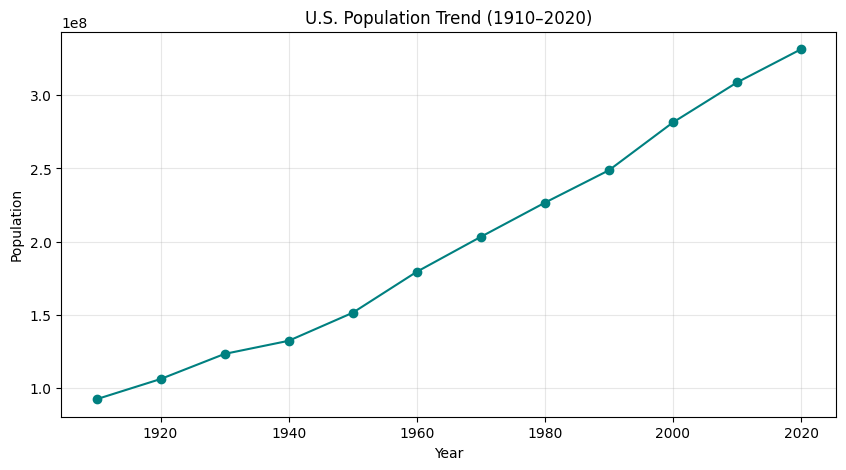

In [4]:

import matplotlib.pyplot as plt
us_df = df[df["Name"] == "United States"].sort_values("Year")
plt.figure(figsize=(10, 5))
plt.plot(us_df["Year"], us_df["Resident Population"], marker="o", color="teal")
plt.title("U.S. Population Trend (1910–2020)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(alpha=0.3)
plt.show()


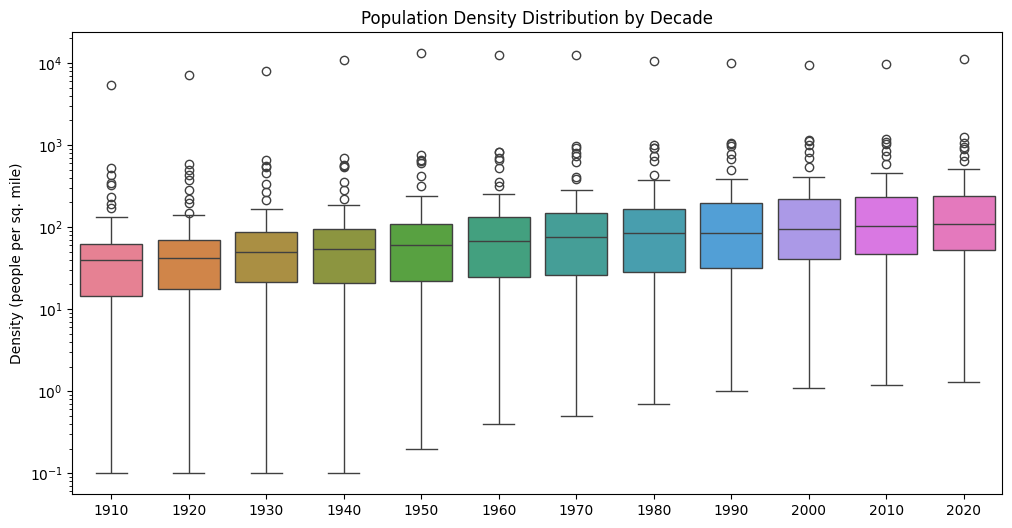

In [7]:

density_df = states_df.groupby("Decade")["Resident Population Density"].apply(list)
plt.figure(figsize=(12, 6))
sns.boxplot(data=[density_df[d] for d in sorted(density_df.index)], orient="v")
plt.xticks(range(len(density_df)), sorted(density_df.index))
plt.title("Population Density Distribution by Decade")
plt.ylabel("Density (people per sq. mile)")
plt.yscale("log")
plt.show()
